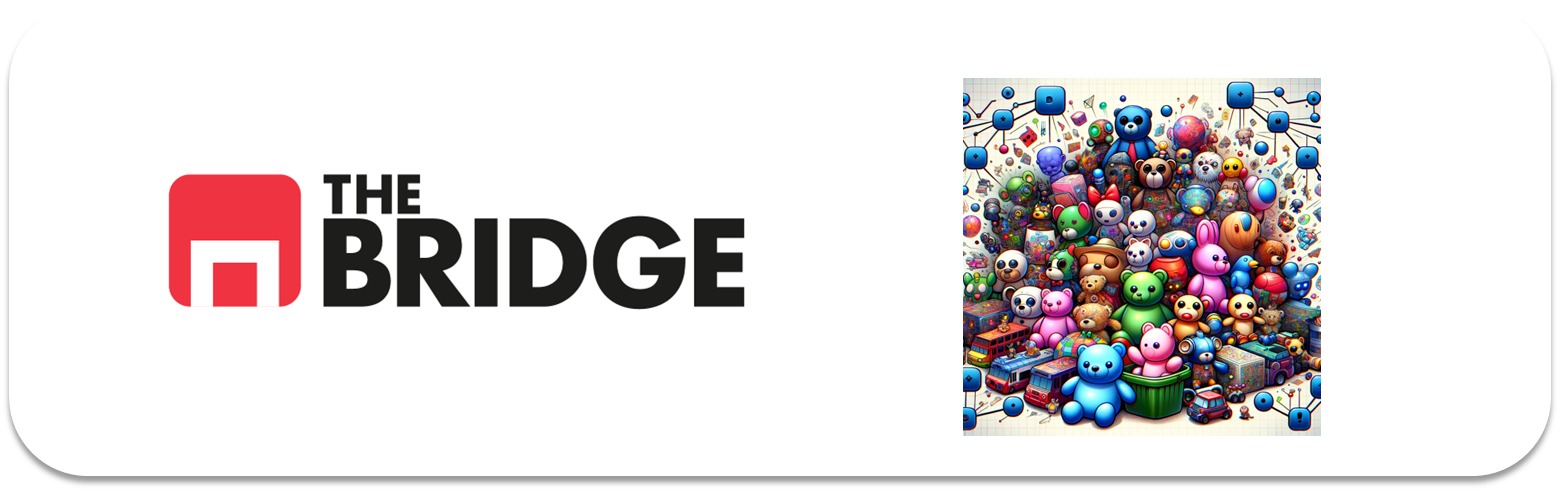

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [51]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

# Combinaciones de variables
from itertools import combinations

# Clustering jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# DBSCAN
from sklearn.cluster import DBSCAN

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Clasificación de nuevos datos
from sklearn.neighbors import KNeighborsClassifier

# Distancias
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


## 1. Entender el problema

El objetivo es segmentar diferentes prototipos de bebidas energéticas a partir de las cantidades de sus componentes, sin disponer de una variable objetivo (`target`) que indique previamente a qué grupo pertenece cada mezcla.

Al no existir un `target`, nos encontramos ante un problema de **aprendizaje no supervisado**, concretamente de **clustering**.

Para abordar el problema se utilizarán dos algoritmos:

- **DBSCAN**, requerido por el enunciado.
- **Clustering Jerárquico**, que además de generar grupos permitirá analizar la relación y similitud entre ellos mediante un dendrograma.

Como referencia de negocio, los químicos esperan obtener entre **3 y 5 segmentos**.

## 2. Cargar datos y visualizar

Se carga el dataset proporcionado por los químicos y se realiza una primera inspección para conocer su estructura antes de comenzar el análisis exploratorio.

In [5]:
df = pd.read_csv("./data/empowering_drinks.csv", sep="|")

df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [6]:
print("Dimensiones del dataset:", df.shape)

df.info()

Dimensiones del dataset: (153, 5)
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


### Conclusión sobre la estructura del dataset

El dataset contiene **153 mezclas** y **5 variables** correspondientes a los diferentes componentes de las bebidas.

Todas las variables son de tipo numérico (`float64`) y presentan **153 valores no nulos**, por lo que en esta primera inspección no se observan valores faltantes.

Esto permite continuar con el análisis exploratorio de las variables antes de aplicar los algoritmos de clustering.

### 2.3 Análisis estadístico descriptivo

Se analizan los principales estadísticos descriptivos de las variables para conocer su distribución, rango de valores y posibles diferencias de escala entre los componentes de las bebidas.

In [7]:
df.describe().round(2)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.00,153.00,153.00,153.00,153.00
mean,0.02,0.04,0.04,0.08,-0.04
std,1.03,1.00,1.04,1.01,0.93
min,-2.43,-3.68,-1.70,-1.49,-1.63
25%,-0.82,-0.50,-1.04,-0.74,-0.80
50%,0.06,-0.02,0.21,-0.17,-0.15
75%,0.88,0.71,0.89,0.92,0.49
max,2.26,3.16,3.06,2.97,2.43


### Conclusión del análisis estadístico

Las cinco variables presentan medias cercanas a **0** y desviaciones estándar próximas a **1**, lo que sugiere que los datos podrían haber sido previamente estandarizados.

Además, las variables se encuentran en escalas similares, por lo que ninguna parece dominar inicialmente el cálculo de distancias debido únicamente a su magnitud.

No obstante, será necesario analizar gráficamente sus distribuciones y relaciones antes de seleccionar las variables que utilizaremos para el clustering.

### 2.4 Distribución de las variables

Se visualiza la distribución de cada componente para identificar su forma, dispersión y posibles valores atípicos antes de analizar las relaciones entre las variables.

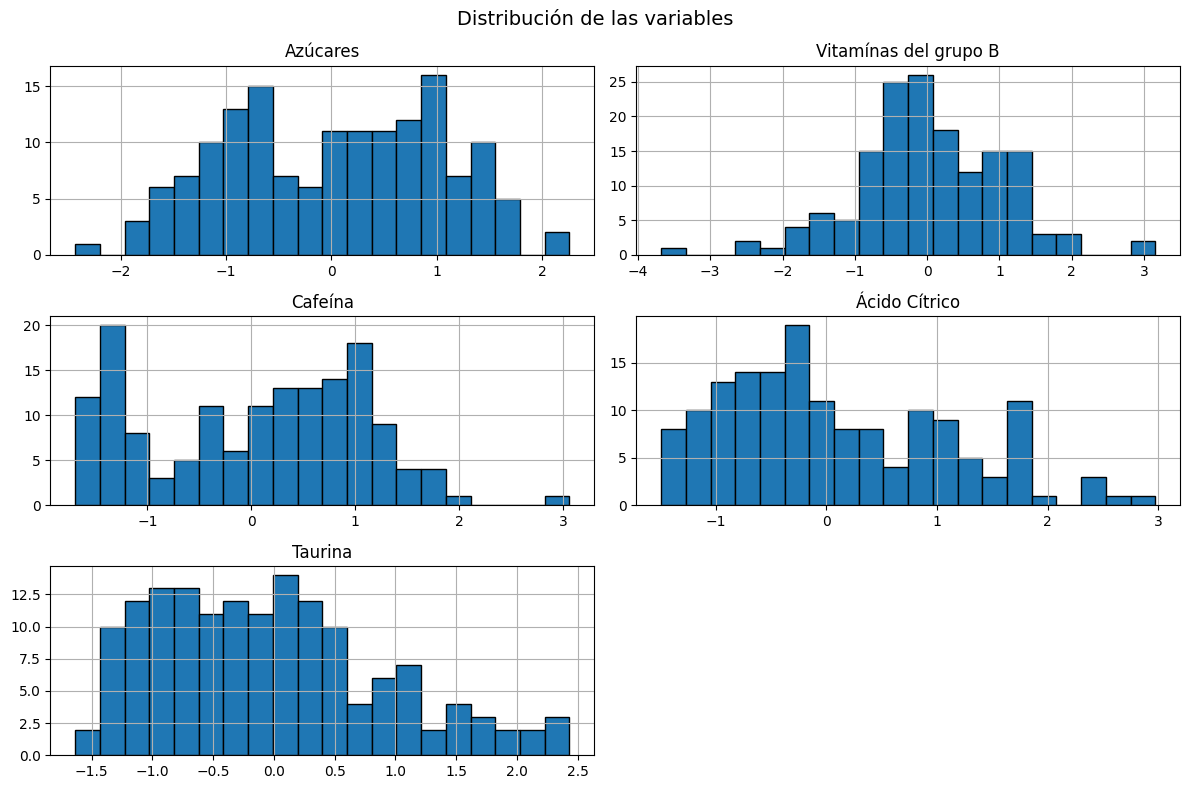

In [8]:
df.hist(
    bins=20,
    figsize=(12, 8),
    edgecolor="black"
)

plt.suptitle("Distribución de las variables", fontsize=14)
plt.tight_layout()
plt.show()

### Conclusión sobre la distribución de las variables

Las variables no presentan distribuciones completamente homogéneas. En algunas, como **Azúcares** y **Cafeína**, se observan diferentes concentraciones de valores que podrían indicar la existencia de grupos dentro de los datos.

También se observan distribuciones asimétricas y algunos valores alejados de las zonas de mayor concentración, especialmente en variables como **Vitaminas del grupo B**, **Ácido Cítrico** y **Taurina**.

Sin embargo, el análisis individual de las variables no permite identificar claramente los posibles segmentos. Por ello, será necesario analizar las relaciones entre las variables **dos a dos** mediante gráficos de dispersión.

### 2.5 Relación entre las variables

Se analizan gráficamente las relaciones entre las variables dos a dos para identificar posibles agrupaciones naturales y determinar qué combinaciones de características pueden resultar más útiles para el clustering.

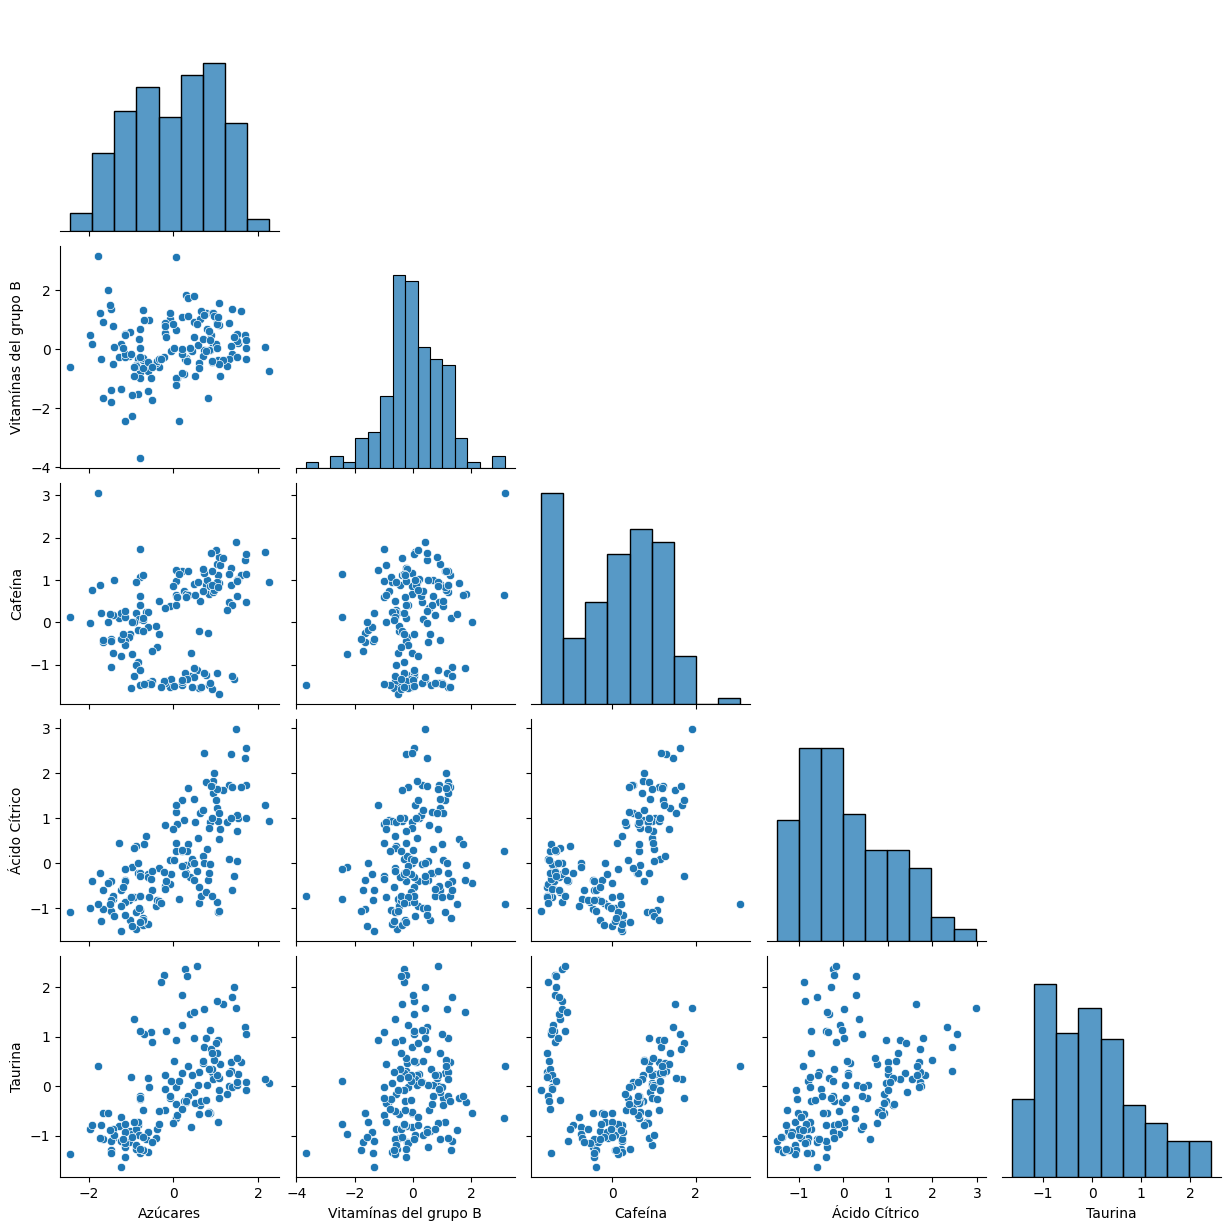

In [10]:
sns.pairplot(
    df,
    corner=True,
    diag_kind="hist"
)

plt.show();

### Conclusión sobre la relación entre las variables

La visualización conjunta permite observar estructuras que no eran evidentes al analizar cada variable de forma individual.

Destaca especialmente **Cafeína**, que al combinarse con variables como **Azúcares**, **Ácido Cítrico** y **Taurina** muestra patrones y concentraciones diferenciadas que podrían resultar útiles para identificar grupos.

Por otro lado, **Vitaminas del grupo B** presenta visualmente una menor capacidad de separación en varias de sus combinaciones.

Estos resultados sugieren que no todas las variables aportan la misma información para el clustering, por lo que se analizarán con mayor detalle las combinaciones más prometedoras antes de seleccionar las features definitivas.

## 3. MiniEDA: Selección de features

A partir de las visualizaciones anteriores se analizará qué variables presentan una mayor capacidad para mostrar agrupaciones naturales en los datos.

Para ello, se estudiarán con mayor detalle las combinaciones de variables más prometedoras antes de decidir qué features utilizar en los modelos de clustering.

### 3.1 Cafeína vs. Azúcares

Se analiza con mayor detalle la relación entre Cafeína y Azúcares para comprobar si la estructura observada en el análisis anterior permite distinguir posibles agrupaciones naturales.

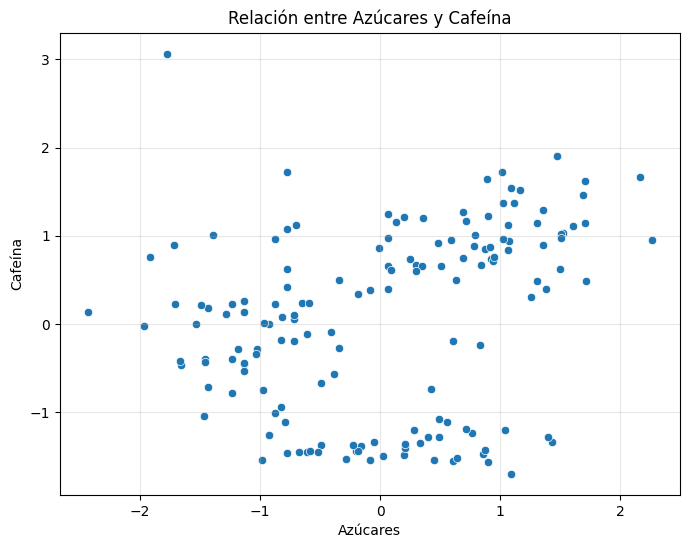

In [11]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Azúcares",
    y="Cafeína"
)

plt.title("Relación entre Azúcares y Cafeína")
plt.xlabel("Azúcares")
plt.ylabel("Cafeína")
plt.grid(alpha=0.3)

plt.show()

#### Conclusión

La relación entre **Azúcares y Cafeína** muestra diferentes zonas de concentración de observaciones, destacando una agrupación en valores bajos de cafeína y otra estructura más dispersa en valores medios y altos.

También se observan algunos puntos aislados respecto a las zonas de mayor densidad, que podrían ser identificados como ruido por un algoritmo como DBSCAN.

Por tanto, esta combinación de variables parece aportar información útil para diferenciar posibles grupos y se considera candidata para la selección de features.

### 3.2 Cafeína vs. Taurina

Se analiza la relación entre Cafeína y Taurina para comprobar si esta combinación permite identificar estructuras o agrupaciones más claras que las observadas anteriormente.

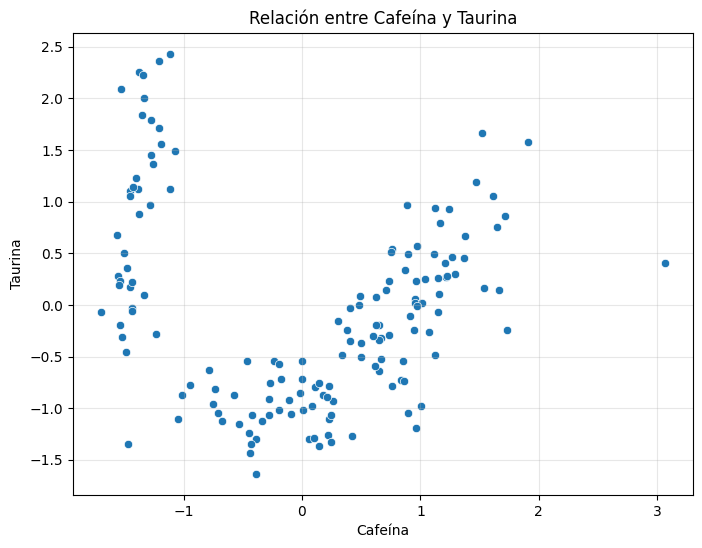

In [12]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Cafeína",
    y="Taurina"
)

plt.title("Relación entre Cafeína y Taurina")
plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.grid(alpha=0.3)

plt.show()

#### Conclusión

La combinación entre **Cafeína y Taurina** muestra una estructura de agrupación más definida. Se observan distintas zonas de concentración y patrones con formas diferentes, además de algunos puntos alejados de las regiones principales.

Esta separación visual sugiere que ambas variables pueden aportar información relevante para identificar grupos mediante clustering, por lo que **Cafeína y Taurina** se consideran buenas candidatas para la selección de features.

### 3.3 Cafeína vs. Ácido Cítrico

Se analiza la relación entre Cafeína y Ácido Cítrico para comprobar si esta combinación presenta estructuras de agrupación que puedan resultar útiles para el clustering.

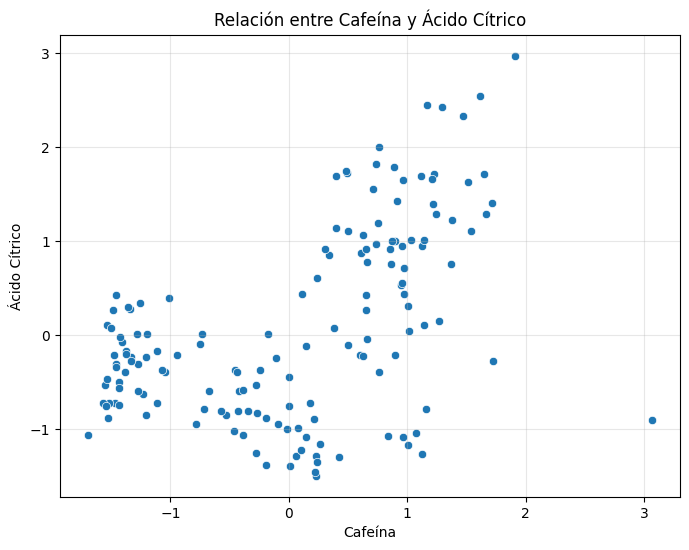

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Cafeína",
    y="Ácido Cítrico"
)

plt.title("Relación entre Cafeína y Ácido Cítrico")
plt.xlabel("Cafeína")
plt.ylabel("Ácido Cítrico")
plt.grid(alpha=0.3)

plt.show()

#### Conclusión

La relación entre **Cafeína y Ácido Cítrico** muestra diferentes zonas de concentración y una separación visual apreciable entre algunos conjuntos de observaciones.

En particular, se distinguen grupos en valores bajos de ambas variables y otras concentraciones en valores medios y altos. También aparecen algunos puntos aislados respecto a las zonas principales.

Por tanto, **Cafeína y Ácido Cítrico** también presentan información útil para diferenciar posibles segmentos.

### 3.4 Selección inicial de features

A partir del análisis visual se seleccionan inicialmente las variables **Azúcares, Cafeína, Ácido Cítrico y Taurina**, ya que sus combinaciones muestran estructuras y zonas de concentración que podrían facilitar la identificación de grupos.

La variable **Vitaminas del grupo B** presenta una menor capacidad de separación visual respecto al resto, por lo que inicialmente se excluye del modelado.

Esta selección es exploratoria y se validará posteriormente observando los resultados obtenidos por los algoritmos de clustering.

In [14]:
features = ["Azúcares", "Cafeína", "Ácido Cítrico", "Taurina"]

X = df[features]

X.head()

,Azúcares,Cafeína,Ácido Cítrico,Taurina
0,1.518613,1.034819,1.013009,0.251717
1,0.246290,0.733629,0.965242,-0.293321
2,0.196879,1.215533,1.395148,0.269020
3,1.691550,1.466525,2.334574,1.186068
4,0.295700,0.663351,-0.037874,-0.319276


#### Conclusión de la selección de features

Se ha creado el conjunto de datos `X` con las cuatro variables seleccionadas: **Azúcares, Cafeína, Ácido Cítrico y Taurina**.

Estas variables fueron seleccionadas porque, durante el análisis visual, mostraron estructuras y concentraciones de observaciones que podrían facilitar la identificación de grupos.

A partir de este conjunto se realizará el tratamiento previo necesario antes de aplicar los algoritmos de clustering.

## 4. Tratamiento de Features

Dado que los algoritmos de clustering que se van a utilizar se basan en distancias entre observaciones, es importante comprobar que las variables se encuentren en escalas comparables.

Antes de aplicar una transformación adicional, se revisarán la media y la desviación estándar de las features seleccionadas para comprobar si los datos ya presentan una escala similar.

### 4.1 Comprobación de la escala de las variables

Se calculan la media y la desviación estándar de las variables seleccionadas para comprobar si es necesario realizar una estandarización adicional.

In [15]:
pd.DataFrame({
    "Media": X.mean(),
    "Desviación estándar": X.std()
}).round(2)

,Media,Desviación estándar
Azúcares,0.02,1.03
Cafeína,0.04,1.04
Ácido Cítrico,0.08,1.01
Taurina,-0.04,0.93


#### Conclusión

Las variables seleccionadas presentan medias cercanas a **0** y desviaciones estándar próximas a **1**, lo que indica que los datos ya se encuentran aproximadamente estandarizados.

Además, todas las features están en escalas comparables, por lo que ninguna debería dominar el cálculo de las distancias únicamente por tener valores de mayor magnitud.

Por este motivo, no se considera necesario aplicar una estandarización adicional y se utilizará directamente el conjunto `X` para el modelado.

## 5. Selección de modelos e hiperparámetros

Se utilizarán dos algoritmos de clustering:

- **DBSCAN**, requerido por el enunciado, que identifica grupos a partir de regiones de alta densidad y permite detectar observaciones consideradas como ruido.
- **Clustering Jerárquico**, que permitirá formar grupos y estudiar la relación de similitud entre ellos mediante un dendrograma.

Para seleccionar los hiperparámetros se tendrá en cuenta la indicación de negocio de que se esperan entre **3 y 5 segmentos**, junto con la estructura observada en los datos.

### 5.1 Selección de hiperparámetros para DBSCAN

DBSCAN utiliza principalmente dos hiperparámetros:

- `eps`: determina la distancia máxima para considerar dos observaciones como vecinas.
- `min_samples`: establece el número mínimo de observaciones necesarias para formar una región densa.

Se probarán diferentes combinaciones de ambos hiperparámetros para observar cuántos clusters genera el modelo y cuántas observaciones identifica como ruido.

In [16]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X)

np.unique(labels_dbscan, return_counts=True)

(array([-1,  0,  1,  2,  3,  4]), array([102,   5,   9,   5,  25,   7]))

#### Primera prueba de DBSCAN

Con `eps=0.5` y `min_samples=5`, DBSCAN identifica **5 clusters**, un número que se encuentra dentro del rango orientativo de 3 a 5 segmentos indicado por los químicos.

Sin embargo, **102 de las 153 observaciones son clasificadas como ruido (`-1`)**, por lo que una gran parte del dataset queda sin asignar a ningún segmento.

Por tanto, aunque el número de clusters obtenido es adecuado, esta configuración presenta demasiado ruido y será necesario probar otros valores de `eps` y `min_samples`.

#### 5.1.1 Prueba de diferentes valores de `eps` y `min_samples`

Se prueban diferentes combinaciones de los hiperparámetros de DBSCAN para analizar cómo afectan al número de clusters encontrados y a la cantidad de observaciones consideradas como ruido.

In [17]:
resultados_dbscan = []

for eps in [0.5, 0.7, 0.9, 1.1]:
    for min_samples in [3, 5, 7]:
        
        modelo = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = modelo.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = np.sum(labels == -1)
        
        resultados_dbscan.append([
            eps,
            min_samples,
            n_clusters,
            n_ruido
        ])

resultados_dbscan = pd.DataFrame(
    resultados_dbscan,
    columns=["eps", "min_samples", "clusters", "ruido"]
)

resultados_dbscan

,eps,min_samples,clusters,ruido
0,0.5,3,12,60
1,0.5,5,5,102
2,0.5,7,2,131
3,0.7,3,4,22
4,0.7,5,4,36
5,0.7,7,4,47
6,0.9,3,3,4
7,0.9,5,2,10
8,0.9,7,2,15
9,1.1,3,1,2


#### Conclusión de la búsqueda de hiperparámetros

Los resultados muestran que DBSCAN es sensible a los valores de `eps` y `min_samples`.

Con valores bajos de `eps`, el modelo genera más clusters pero también clasifica una gran cantidad de observaciones como ruido. Al aumentar `eps`, disminuye el ruido, pero los grupos comienzan a fusionarse hasta formar uno o dos clusters.

La combinación `eps=0.7` y `min_samples=3` presenta inicialmente un buen equilibrio, ya que identifica **4 clusters**, dentro del rango de 3 a 5 segmentos esperado por los químicos, y reduce el ruido a **22 observaciones**.

No obstante, antes de seleccionar esta configuración definitivamente se analizará visualmente la distribución de los clusters obtenidos.

#### 5.1.2 Evolución del porcentaje de ruido según `eps`

Para analizar con mayor detalle el comportamiento de DBSCAN, se probarán diferentes valores de `eps` para varios valores de `min_samples`.

Se representará el porcentaje de observaciones clasificadas como ruido (`-1`) para estudiar cómo cambia la detección de anomalías a medida que aumenta el radio de vecindad.

In [21]:
experimentos = {}

for min_samples in [3, 5, 7, 10]:
    
    porcentaje_ruido = []
    
    for eps in np.linspace(0.1, 2, 50):
        
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan.fit_predict(X)
        
        ruido = 100 * np.sum(labels == -1) / len(labels)
        porcentaje_ruido.append(ruido)
    
    experimentos[min_samples] = porcentaje_ruido

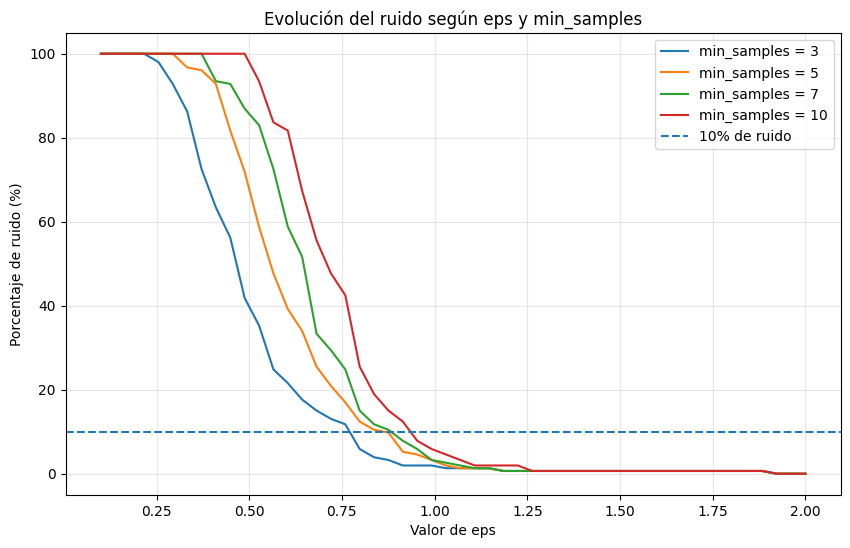

In [22]:
plt.figure(figsize=(10, 6))

for min_samples in [3, 5, 7, 10]:
    sns.lineplot(
        x=np.linspace(0.1, 2, 50),
        y=experimentos[min_samples],
        label=f"min_samples = {min_samples}"
    )

plt.axhline(
    10,
    linestyle="--",
    label="10% de ruido"
)

plt.xlabel("Valor de eps")
plt.ylabel("Porcentaje de ruido (%)")
plt.title("Evolución del ruido según eps y min_samples")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Conclusión sobre la evolución del ruido

La gráfica muestra que el porcentaje de observaciones clasificadas como ruido disminuye a medida que aumenta `eps`, ya que un mayor radio de vecindad permite conectar más observaciones dentro de los clusters.

También se observa que valores mayores de `min_samples` son más restrictivos y requieren, en general, valores superiores de `eps` para reducir el porcentaje de ruido.

La zona comprendida aproximadamente entre `eps = 0.7` y `eps = 1.0` resulta especialmente interesante, ya que en ella el porcentaje de ruido disminuye de forma considerable.

Sin embargo, el porcentaje de ruido no es suficiente para seleccionar el modelo definitivo, por lo que también se analizarán el número de clusters obtenidos y su estructura visual.

#### 5.1.3 Visualización de los clusters de DBSCAN

Se representa gráficamente la configuración `eps=0.7` y `min_samples=3` para analizar cómo se distribuyen los clusters encontrados en las diferentes combinaciones de features.

Las observaciones etiquetadas como `-1` corresponden a puntos considerados como ruido por DBSCAN.

In [23]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=3
)

labels_dbscan = dbscan.fit_predict(X)

df_dbscan = X.copy()
df_dbscan["Cluster"] = labels_dbscan

df_dbscan["Cluster"].value_counts().sort_index()

Cluster
-1    22
 0    53
 1    43
 2    32
 3     3
Name: count, dtype: int64

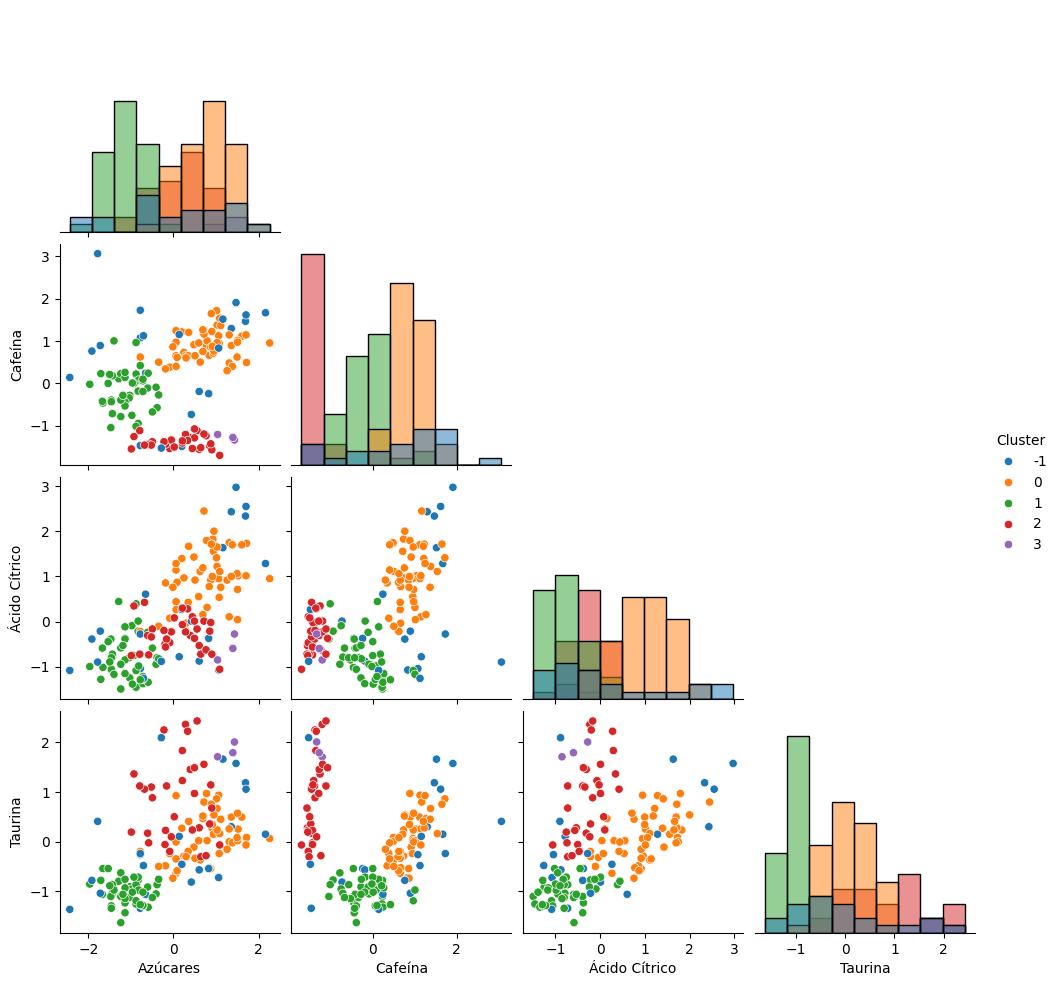

In [24]:
sns.pairplot(
    df_dbscan,
    vars=features,
    hue="Cluster",
    corner=True,
    diag_kind="hist",
    palette="tab10"
)

plt.show()

#### Conclusión de la visualización de DBSCAN

Con `eps=0.7` y `min_samples=3`, DBSCAN identifica **4 clusters** y clasifica **22 observaciones como ruido**.

La visualización muestra que los clusters principales presentan estructuras diferenciadas en varias combinaciones de variables, especialmente en aquellas en las que intervienen **Cafeína, Taurina y Ácido Cítrico**.

Sin embargo, los grupos presentan tamaños desiguales: los clusters 0, 1 y 2 contienen 53, 43 y 32 observaciones respectivamente, mientras que el cluster 3 está formado únicamente por 3 observaciones. Por tanto, aunque el modelo cumple la orientación de obtener entre 3 y 5 segmentos, conviene analizar si este pequeño cuarto cluster representa realmente una estructura diferenciada o es consecuencia de los hiperparámetros seleccionados.

Además, DBSCAN identifica 22 observaciones como ruido, lo que refleja su capacidad para separar puntos que no pertenecen a regiones suficientemente densas.

#### 5.1.4 Visualización detallada de Cafeína y Taurina

Se representa la combinación de Cafeína y Taurina coloreando las observaciones según el cluster asignado por DBSCAN, ya que esta combinación mostró una separación especialmente clara durante el análisis exploratorio.

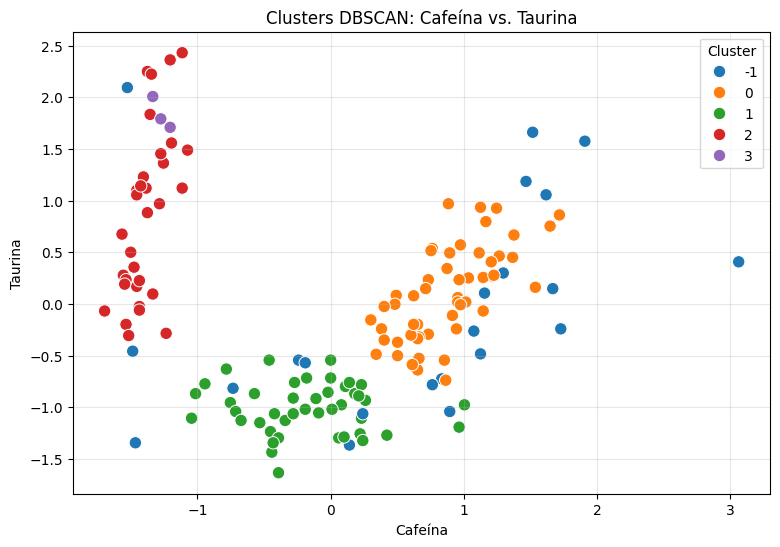

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_dbscan,
    x="Cafeína",
    y="Taurina",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title("Clusters DBSCAN: Cafeína vs. Taurina")
plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.grid(alpha=0.3)
plt.legend(title="Cluster")

plt.show()

#### Conclusión de la visualización Cafeína vs. Taurina

La representación de **Cafeína y Taurina** permite observar claramente la estructura encontrada por DBSCAN.

Los clusters 0, 1 y 2 forman agrupaciones visualmente diferenciadas, mientras que el cluster 3 contiene únicamente 3 observaciones y se encuentra muy próximo al cluster 2.

También se observan varios puntos clasificados como ruido (`-1`), principalmente alejados de las regiones de mayor densidad.

Aunque la configuración `eps=0.7` y `min_samples=3` genera 4 clusters, la visualización sugiere que el cuarto grupo podría ser consecuencia de una segmentación demasiado específica. Por ello, se compararán otras configuraciones antes de seleccionar los hiperparámetros definitivos.

#### 5.1.5 Comparación visual de configuraciones DBSCAN

Se comparan diferentes configuraciones de `eps` y `min_samples` para observar cómo afectan a la formación de los clusters.

Para facilitar la interpretación se utiliza la combinación **Cafeína-Taurina**, que mostró una estructura especialmente clara en el análisis exploratorio. Los puntos etiquetados como `-1` representan las observaciones consideradas como ruido.

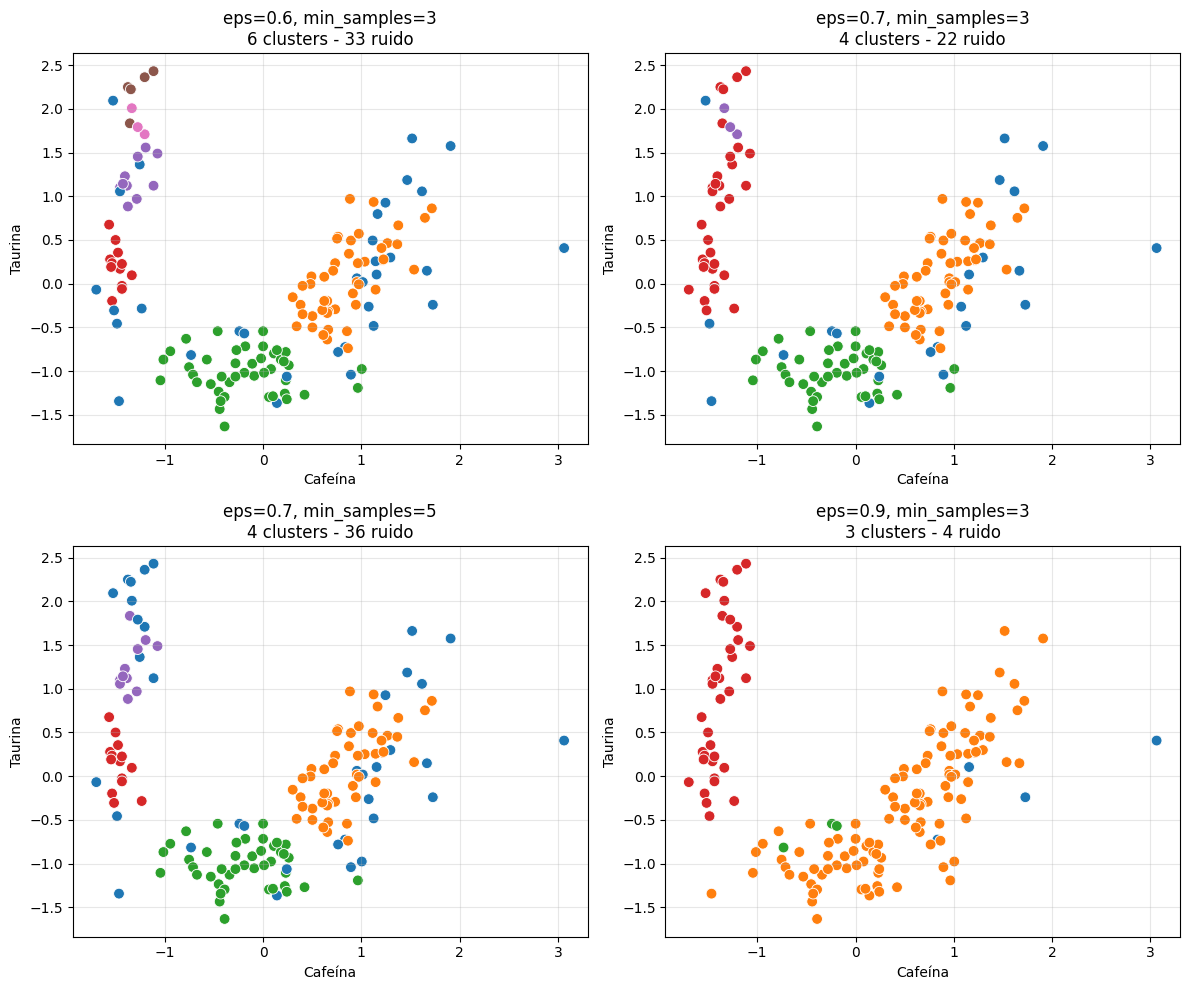

In [26]:
configuraciones = [
    (0.6, 3),
    (0.7, 3),
    (0.7, 5),
    (0.9, 3)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (eps, min_samples) in zip(axes.flatten(), configuraciones):

    modelo = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = modelo.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = np.sum(labels == -1)

    sns.scatterplot(
        x=X["Cafeína"],
        y=X["Taurina"],
        hue=labels,
        palette="tab10",
        s=60,
        ax=ax,
        legend=False
    )

    ax.set_title(
        f"eps={eps}, min_samples={min_samples}\n"
        f"{n_clusters} clusters - {n_ruido} ruido"
    )

    ax.set_xlabel("Cafeína")
    ax.set_ylabel("Taurina")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Conclusión de la comparación de configuraciones

La comparación visual confirma que los hiperparámetros de DBSCAN modifican considerablemente la estructura de los grupos obtenidos.

Con `eps=0.6` y `min_samples=3` el modelo genera 6 clusters y fragmenta excesivamente los datos. Al utilizar `eps=0.7`, se obtienen 4 clusters, dentro del rango esperado por los químicos, aunque aparece un grupo de tamaño reducido.

Al aumentar `min_samples` de 3 a 5 con `eps=0.7`, se mantiene el mismo número de clusters pero aumenta considerablemente el número de observaciones clasificadas como ruido.

Por otro lado, con `eps=0.9` y `min_samples=3` el ruido se reduce a solo 4 observaciones y se obtienen 3 clusters, pero visualmente algunas estructuras que anteriormente aparecían diferenciadas quedan unidas dentro del mismo grupo.

Por este motivo, se considera que `eps=0.7` y `min_samples=3` ofrece un equilibrio razonable entre el número de segmentos, el nivel de ruido y la conservación de la estructura observada en los datos.

#### 5.1.6 Modelo DBSCAN seleccionado

Tras comparar diferentes combinaciones de hiperparámetros, se selecciona como modelo final de DBSCAN la configuración:

- `eps = 0.7`
- `min_samples = 3`

Esta configuración genera **4 clusters** y clasifica **22 observaciones como ruido**.

In [28]:
best_dbscan = DBSCAN(
    eps=0.7,
    min_samples=3
)

labels_dbscan = best_dbscan.fit_predict(X)

df_dbscan = X.copy()
df_dbscan["Cluster"] = labels_dbscan

df_dbscan["Cluster"].value_counts().sort_index()

Cluster
-1    22
 0    53
 1    43
 2    32
 3     3
Name: count, dtype: int64

### 5.2 Clustering Jerárquico

Como segundo algoritmo se utilizará **Clustering Jerárquico**, ya que además de permitir segmentar las mezclas, facilita el análisis de las relaciones de similitud entre los grupos.

Mediante un **dendrograma** se podrá observar cómo las diferentes observaciones y grupos se van fusionando progresivamente en función de su distancia.

#### 5.2.1 Construcción del dendrograma

Se construye un dendrograma utilizando las features seleccionadas para analizar visualmente la estructura jerárquica de los datos y determinar un número adecuado de clusters.

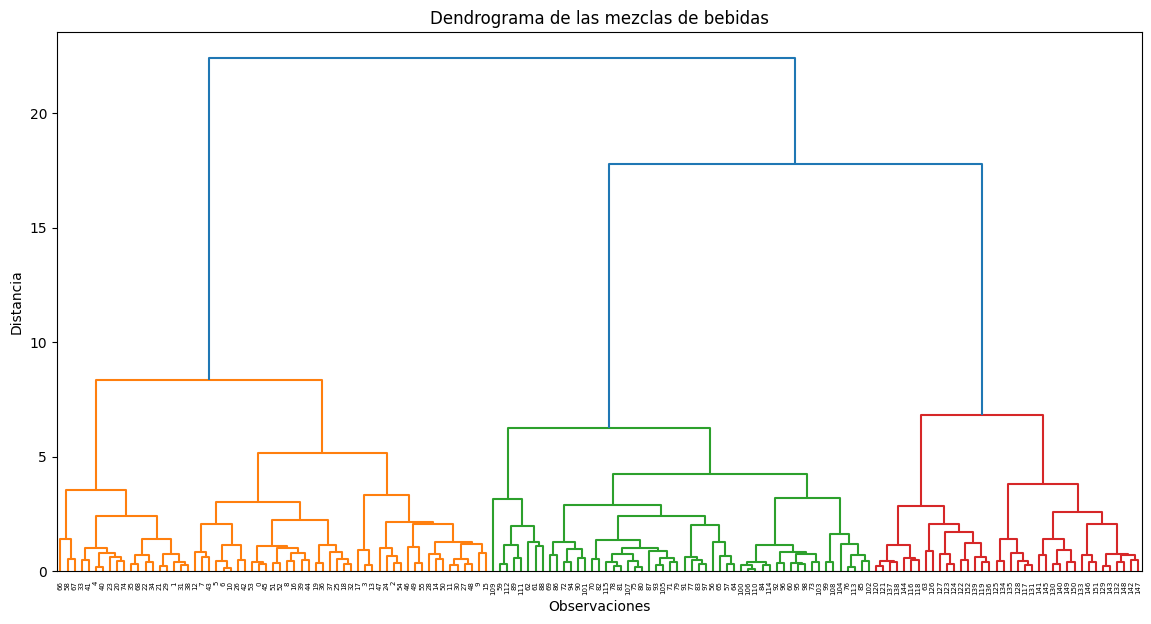

In [29]:
Z = linkage(
    X,
    method="ward"
)

plt.figure(figsize=(14, 7))

dendrogram(Z)

plt.title("Dendrograma de las mezclas de bebidas")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")

plt.show()

#### Conclusión del dendrograma

El dendrograma muestra una estructura jerárquica en la que se distinguen visualmente **tres grandes grupos**, un número que se encuentra dentro del rango orientativo de 3 a 5 segmentos indicado por los químicos.

Además, se observan saltos importantes en las distancias de unión de los grupos, lo que respalda la existencia de una estructura diferenciada en los datos.

La representación jerárquica también permite estudiar la relación entre los segmentos: los grupos correspondientes a las ramas verde y roja se unen entre sí a una distancia menor que aquella necesaria para unirlos con la rama naranja, lo que sugiere una mayor similitud entre estos grupos.

#### 5.2.2 Selección del número de clusters

A partir de la estructura observada en el dendrograma se seleccionan inicialmente **3 clusters** para el modelo jerárquico.

Esta elección se encuentra dentro del rango esperado por el negocio y permite conservar las tres grandes agrupaciones observadas visualmente.

In [30]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels_hierarchical = hierarchical.fit_predict(X)

np.unique(labels_hierarchical, return_counts=True)

(array([0, 1, 2]), array([61, 38, 54]))

#### Conclusión de la selección de clusters

El modelo de Clustering Jerárquico con `n_clusters=3` genera tres segmentos formados por **61, 38 y 54 observaciones**.

Los grupos presentan tamaños relativamente equilibrados y, a diferencia de DBSCAN, todas las observaciones quedan asignadas a un cluster.

No obstante, es necesario visualizar la distribución de estos grupos para comprobar si la segmentación obtenida mantiene la estructura observada previamente en los datos.

#### 5.2.3 Visualización de los clusters jerárquicos

Se representan los clusters obtenidos mediante Clustering Jerárquico utilizando las variables **Cafeína y Taurina**, que mostraron una estructura clara durante el análisis exploratorio.

Esta visualización permitirá comparar posteriormente la segmentación obtenida con la generada por DBSCAN.

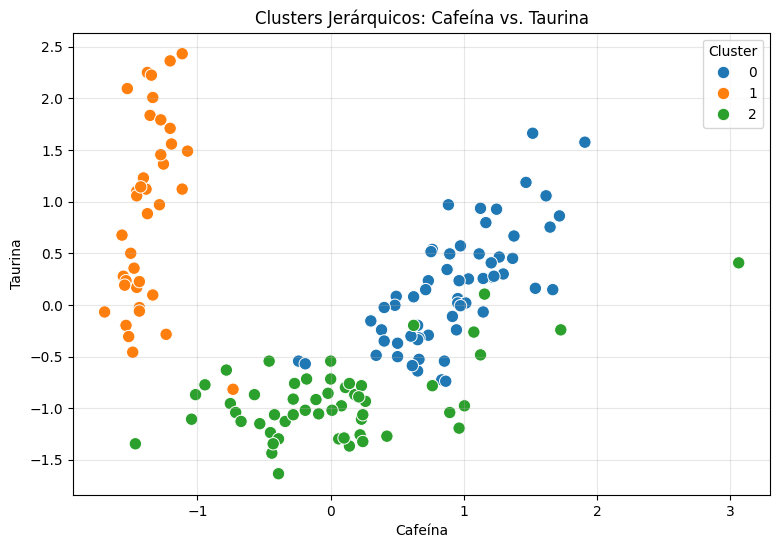

In [31]:
df_hierarchical = X.copy()
df_hierarchical["Cluster"] = labels_hierarchical

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_hierarchical,
    x="Cafeína",
    y="Taurina",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title("Clusters Jerárquicos: Cafeína vs. Taurina")
plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.grid(alpha=0.3)
plt.legend(title="Cluster")

plt.show()

#### Conclusión de la visualización de los clusters jerárquicos

La representación de **Cafeína y Taurina** muestra tres agrupaciones visualmente diferenciadas y coherentes con las estructuras observadas durante el análisis exploratorio.

El Clustering Jerárquico consigue separar la rama de baja cafeína, la concentración de valores bajos de taurina y la estructura ascendente asociada principalmente a valores medios y altos de cafeína.

A diferencia de DBSCAN, todas las observaciones son asignadas a alguno de los tres clusters. Esto incluye algunos puntos alejados de las zonas principales que DBSCAN había identificado como ruido.

#### 5.2.4 Visualización conjunta de los clusters jerárquicos

Se representan las diferentes combinaciones de features coloreadas según el cluster asignado para comprobar si la separación observada en Cafeína y Taurina también se mantiene en el resto de variables.

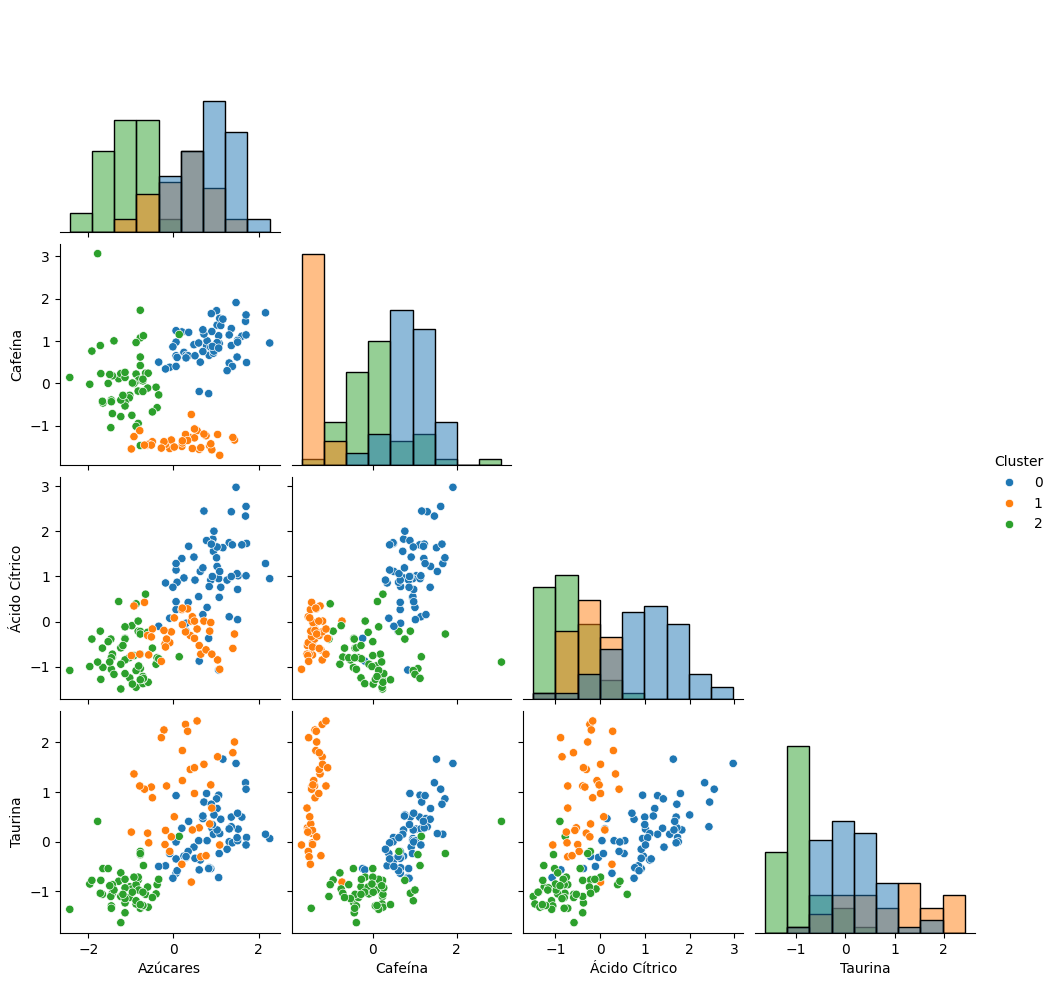

In [32]:
sns.pairplot(
    df_hierarchical,
    vars=features,
    hue="Cluster",
    corner=True,
    diag_kind="hist",
    palette="tab10"
)

plt.show()

#### Conclusión de la visualización conjunta

El análisis conjunto de las features confirma que los **tres clusters jerárquicos mantienen patrones diferenciados en varias combinaciones de variables**.

Las variables **Cafeína, Ácido Cítrico y Taurina** muestran una separación especialmente clara entre los grupos, mientras que en otras combinaciones existe un mayor grado de solapamiento.

La estructura observada es coherente con el dendrograma y respalda la utilización de tres segmentos. Además, el modelo asigna todas las mezclas a alguno de los grupos, incluso aquellas observaciones más alejadas de las regiones principales.

## 6. Comparación de modelos y discusión de resultados

Una vez construidos los modelos de **DBSCAN** y **Clustering Jerárquico**, se comparan los resultados obtenidos para analizar las principales diferencias entre ambas segmentaciones.

La comparación tendrá en cuenta el número de clusters, el tamaño de los grupos, la presencia de ruido y la estructura observada en las visualizaciones.

### 6.1 Resumen de los resultados

Se resumen las principales características de las segmentaciones obtenidas con ambos algoritmos.

In [33]:
comparacion = pd.DataFrame({
    "Modelo": ["DBSCAN", "Clustering Jerárquico"],
    "Nº clusters": [4, 3],
    "Tamaño clusters": ["53, 43, 32, 3", "61, 38, 54"],
    "Observaciones ruido": [22, 0],
    "Asigna todas las observaciones": ["No", "Sí"]
})

comparacion

,Modelo,Nº clusters,Tamaño clusters,Observaciones ruido,Asigna todas las observaciones
0,DBSCAN,4,"53, 43, 32, 3",22,No
1,Clustering Jerárquico,3,"61, 38, 54",0,Sí


### 6.2 Discusión de los resultados

Los dos algoritmos encuentran una estructura de segmentación en las mezclas, aunque presentan diferencias en la forma de construir los grupos.

**DBSCAN** identifica 4 clusters y clasifica 22 observaciones como ruido. Tres de los grupos presentan tamaños considerables, mientras que el cuarto contiene únicamente 3 observaciones. Su principal ventaja en este caso es que permite detectar mezclas alejadas de las regiones de mayor densidad sin obligarlas a pertenecer a un segmento.

Por su parte, el **Clustering Jerárquico** genera 3 clusters de tamaños más equilibrados (61, 38 y 54 observaciones) y asigna todas las mezclas a alguno de ellos. Además, el dendrograma permite estudiar la relación de similitud entre los grupos, respondiendo al interés del negocio por conocer qué segmentos se encuentran más relacionados entre sí.

Las visualizaciones muestran que ambos métodos detectan estructuras similares en los datos, especialmente en las relaciones entre Cafeína, Taurina y Ácido Cítrico, aunque realizan asignaciones diferentes en determinadas observaciones.

### 6.3 ¿Por qué la comparación es especulativa?

La comparación entre ambos modelos es **especulativa** porque se trata de un problema de aprendizaje no supervisado y no disponemos de un `target` que indique cuál debería ser el segmento correcto de cada mezcla.

Además, las bebidas todavía no han sido evaluadas mediante pruebas de sabor, capacidad antifatiga o preferencia de los usuarios. Por tanto, no podemos comprobar si los clusters encontrados representan realmente diferencias relevantes desde el punto de vista del negocio.

Podemos analizar la cohesión y separación visual de los grupos y comparar el comportamiento de los algoritmos, pero la interpretación final de los segmentos deberá realizarse posteriormente junto con los químicos y, eventualmente, contrastarse con resultados reales de las pruebas de producto.

### 6.4 Caracterización de los segmentos

Para facilitar la interpretación de la segmentación obtenida, se analizan los valores medios de cada componente en los clusters generados mediante Clustering Jerárquico.

Esto permitirá identificar qué características diferencian principalmente a cada grupo de mezclas.

In [34]:
perfil_clusters = (
    df_hierarchical
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

perfil_clusters

,Azúcares,Cafeína,Ácido Cítrico,Taurina
Cluster,,,,
0,0.88,0.92,1.04,0.15
1,0.20,-1.37,-0.29,0.89
2,-1.08,0.04,-0.74,-0.92


#### 6.4.1 Perfil medio de los clusters

Se representan gráficamente los valores medios de las features para cada cluster con el objetivo de facilitar la comparación entre los perfiles de las diferentes mezclas.

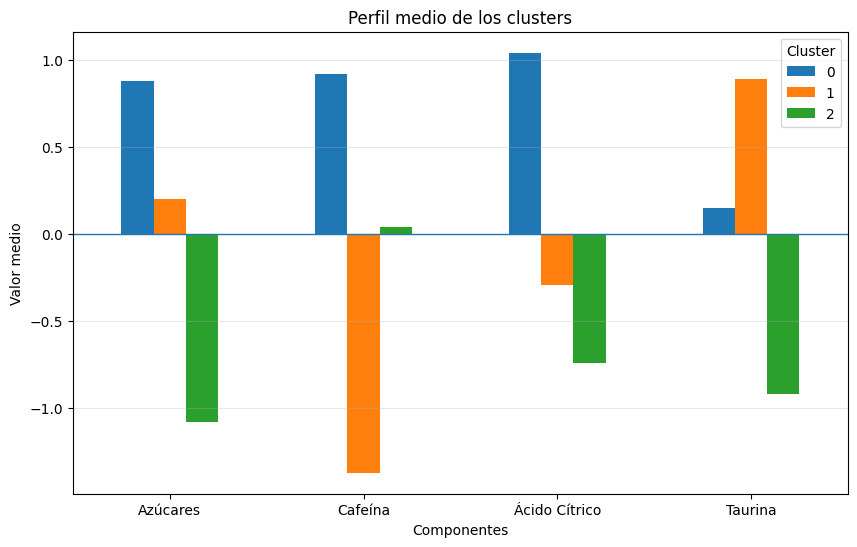

In [35]:
perfil_clusters.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(0, linewidth=1)
plt.title("Perfil medio de los clusters")
plt.xlabel("Componentes")
plt.ylabel("Valor medio")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Conclusión sobre el perfil de los segmentos

Los tres clusters presentan perfiles claramente diferenciados según la composición de las mezclas:

- **Cluster 0:** se caracteriza por valores relativamente altos de **Azúcares, Cafeína y Ácido Cítrico**, mientras que la Taurina se mantiene ligeramente por encima de la media.

- **Cluster 1:** destaca principalmente por presentar **Taurina elevada y Cafeína muy baja**. Los Azúcares se encuentran ligeramente por encima de la media y el Ácido Cítrico ligeramente por debajo.

- **Cluster 2:** presenta valores relativamente bajos de **Azúcares, Ácido Cítrico y Taurina**, mientras que la Cafeína se mantiene próxima a la media.

Estos perfiles permiten describir los segmentos a partir de la composición de las bebidas. Sin embargo, no permiten determinar todavía cuál de ellos presenta mejores propiedades antifatiga o mayor aceptación, ya que no se dispone de resultados de pruebas con usuarios.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

### 7.1 Carga e inspección de los nuevos experimentos

Se carga el dataset con las nuevas mezclas y se comprueba su estructura antes de realizar la segmentación.

In [36]:
new_experiments = pd.read_csv(
    "./data/new_experiments.csv",
    sep="|"
)

new_experiments.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


### 7.2 Comprobación de la estructura de los nuevos experimentos

Antes de realizar la segmentación, se comprueba el número de observaciones, los tipos de datos y la posible presencia de valores nulos.

También se verifica que estén disponibles las mismas features utilizadas durante la construcción de los modelos.

In [37]:
print("Dimensiones:", new_experiments.shape)

new_experiments.info()

print("\nValores nulos:")
print(new_experiments.isnull().sum())

Dimensiones: (6, 5)
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               6 non-null      float64
 1   Vitamínas del grupo B  6 non-null      float64
 2   Cafeína                6 non-null      float64
 3   Ácido Cítrico          6 non-null      float64
 4   Taurina                6 non-null      float64
dtypes: float64(5)
memory usage: 372.0 bytes

Valores nulos:
Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


#### Conclusión

El dataset contiene **6 nuevos experimentos y 5 variables**, todas de tipo numérico y sin valores nulos.

Las variables necesarias para aplicar la segmentación están disponibles. Para mantener la coherencia con el modelado realizado en la Parte I, se utilizarán únicamente las mismas cuatro features seleccionadas anteriormente.

### 7.3 Preparación de los nuevos experimentos

Se seleccionan las mismas features utilizadas durante el entrenamiento para garantizar que los nuevos experimentos tengan exactamente la misma estructura que los datos empleados en la construcción de los clusters.

In [38]:
X_new = new_experiments[features]

X_new

,Azúcares,Cafeína,Ácido Cítrico,Taurina
0,1.481555,1.366128,2.239039,0.731870
1,0.616869,0.583034,0.312420,-0.665332
2,-1.680724,-0.340615,-0.213021,-0.976782
3,-0.284874,-0.782361,-1.193845,-0.717240
4,-0.927212,-1.565455,-0.085641,-0.522583
5,0.962743,-1.354622,-0.420013,1.956043


### 7.4 Cálculo de los centroides de los segmentos

El modelo de Clustering Jerárquico no dispone de un método `predict()` para clasificar directamente nuevas observaciones.

Por ello, se calculará el centroide de cada uno de los tres segmentos obtenidos y posteriormente cada nuevo experimento se asignará al cluster cuyo centroide se encuentre más próximo.

In [39]:
centroides = (
    df_hierarchical
    .groupby("Cluster")[features]
    .mean()
)

centroides.round(2)

,Azúcares,Cafeína,Ácido Cítrico,Taurina
Cluster,,,,
0,0.88,0.92,1.04,0.15
1,0.20,-1.37,-0.29,0.89
2,-1.08,0.04,-0.74,-0.92


### 7.5 Asignación de los nuevos experimentos a los segmentos

Para segmentar los nuevos experimentos se calcula la distancia euclídea entre cada nueva mezcla y los centroides de los tres clusters.

Cada experimento se asignará al cluster cuyo centroide presente la menor distancia.

In [41]:
distancias = cdist(
    X_new,
    centroides,
    metric="euclidean"
)

distancias

array([[1.52724041, 3.94325809, 4.46669545],
       [1.17552386, 2.59796113, 2.08848337],
       [3.31781765, 2.83997398, 0.88301145],
       [3.16304677, 1.98918153, 1.2490076 ],
       [3.34316654, 1.82744731, 1.78404636],
       [3.24943309, 1.31968063, 3.80960416]])

### 7.6 Resultado de la segmentación de los nuevos experimentos

A partir de las distancias calculadas, cada nuevo experimento se asigna al cluster cuyo centroide se encuentra más próximo.

Se muestran las distancias a cada uno de los tres centroides junto con el segmento finalmente asignado.

In [43]:
cluster_asignado = np.argmin(distancias, axis=1)

resultado_nuevos = pd.DataFrame({
    "Experimento": range(1, len(X_new) + 1),
    "Distancia Cluster 0": distancias[:, 0],
    "Distancia Cluster 1": distancias[:, 1],
    "Distancia Cluster 2": distancias[:, 2],
    "Cluster asignado": cluster_asignado
})

resultado_nuevos.round(2)

,Experimento,Distancia Cluster 0,Distancia Cluster 1,Distancia Cluster 2,Cluster asignado
0,1,1.53,3.94,4.47,0
1,2,1.18,2.60,2.09,0
2,3,3.32,2.84,0.88,2
3,4,3.16,1.99,1.25,2
4,5,3.34,1.83,1.78,2
5,6,3.25,1.32,3.81,1


#### Conclusión de la segmentación de los nuevos experimentos

Los nuevos experimentos han sido asignados al segmento cuyo centroide presenta la menor distancia euclídea.

Los experimentos **1 y 2** se asignan al **Cluster 0**, los experimentos **3, 4 y 5** al **Cluster 2**, y el experimento **6** al **Cluster 1**.

La mayoría de las asignaciones presentan diferencias claras entre la distancia al cluster seleccionado y las distancias a los demás grupos. Sin embargo, el **experimento 5** presenta distancias muy similares a los clusters 1 y 2, por lo que su asignación al Cluster 2 debe interpretarse con mayor cautela.

### 7.7 Visualización de los nuevos experimentos

Se representan los nuevos experimentos sobre la segmentación obtenida utilizando las variables **Cafeína y Taurina**.

Los puntos representan las mezclas originales y las cruces (`X`) identifican los nuevos experimentos, coloreados según el cluster al que han sido asignados.

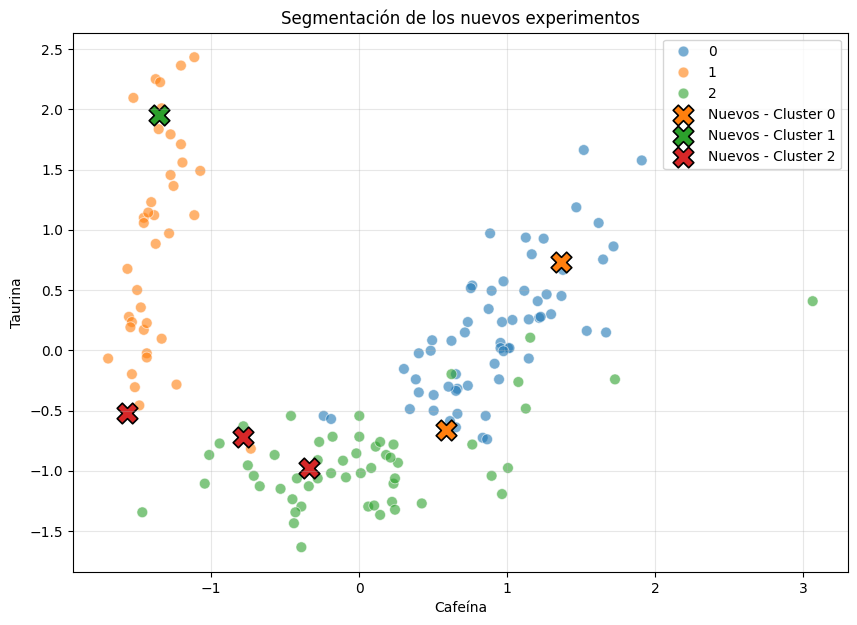

In [44]:
plt.figure(figsize=(10, 7))

# Mezclas originales
sns.scatterplot(
    data=df_hierarchical,
    x="Cafeína",
    y="Taurina",
    hue="Cluster",
    palette="tab10",
    s=60,
    alpha=0.6
)

# Nuevos experimentos
for cluster in sorted(np.unique(cluster_asignado)):
    
    mask = cluster_asignado == cluster
    
    plt.scatter(
        X_new.loc[mask, "Cafeína"],
        X_new.loc[mask, "Taurina"],
        marker="X",
        s=220,
        edgecolor="black",
        linewidth=1.2,
        label=f"Nuevos - Cluster {cluster}"
    )

plt.title("Segmentación de los nuevos experimentos")
plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

#### Conclusión de los nuevos experimentos

La representación permite visualizar la posición de los nuevos experimentos respecto a los segmentos obtenidos mediante Clustering Jerárquico.

Los experimentos **1 y 2** han sido asignados al **Cluster 0**, los experimentos **3, 4 y 5** al **Cluster 2**, y el experimento **6** al **Cluster 1**.

Visualmente, los nuevos experimentos se sitúan en zonas compatibles con las estructuras observadas en los datos originales. No obstante, esta representación utiliza únicamente **Cafeína y Taurina**, mientras que la asignación se ha realizado considerando conjuntamente las cuatro features seleccionadas.

Por tanto, la gráfica debe utilizarse como apoyo visual de la segmentación y no como único criterio para determinar la pertenencia a cada cluster.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

## Parte III. EXTRA - Evaluación de la segmentación

Seis meses después se dispone de los resultados obtenidos mediante pruebas con clientes, que clasifican las bebidas según su nivel de energización:

- **1:** media
- **2:** media-alta
- **3:** alta

Estos resultados permiten evaluar a posteriori si los segmentos obtenidos mediante los algoritmos de clustering guardan relación con los niveles reales de energización.

### 8.1 Carga e inspección de los resultados de energización

Se carga el fichero con los resultados de las pruebas realizadas a los clientes para conocer su estructura y comprobar que los datos están alineados con los experimentos utilizados anteriormente.

In [45]:
power_results = pd.read_csv(
    "./data/power_results.csv",
    sep="|"
)

power_results.head()

,class
0,1
1,1
2,1
3,1
4,1


### 8.2 Comprobación de los resultados reales

Se comprueba el número total de resultados disponibles y la distribución de los niveles de energización obtenidos en las pruebas con clientes.

Esto permitirá verificar que los resultados están alineados con las mezclas originales y los nuevos experimentos utilizados anteriormente.

In [46]:
print("Dimensiones:", power_results.shape)

print("\nDistribución de las clases:")
print(power_results["class"].value_counts().sort_index())

Dimensiones: (159, 1)

Distribución de las clases:
class
1    58
2    62
3    39
Name: count, dtype: int64


#### Conclusión

El fichero contiene **159 resultados**, que coinciden exactamente con las **153 mezclas originales** y los **6 nuevos experimentos** analizados anteriormente.

Las pruebas con clientes han generado tres niveles de energización:

- Clase 1: 58 bebidas.
- Clase 2: 62 bebidas.
- Clase 3: 39 bebidas.

Por tanto, los resultados pueden utilizarse para evaluar a posteriori la relación entre los clusters obtenidos y los niveles reales de energización.

### 8.3 Separación de los resultados

Como los resultados están alineados con los experimentos originales y, al final, con los nuevos experimentos, se separan ambos conjuntos para poder evaluar correctamente las segmentaciones construidas en la Parte I.

In [47]:
y_original = power_results["class"].iloc[:len(df)].reset_index(drop=True)
y_new = power_results["class"].iloc[len(df):].reset_index(drop=True)

print("Resultados originales:", len(y_original))
print("Resultados nuevos:", len(y_new))

print("\nClases originales:")
print(y_original.value_counts().sort_index())

print("\nClases nuevos experimentos:")
print(y_new.value_counts().sort_index())

Resultados originales: 153
Resultados nuevos: 6

Clases originales:
class
1    56
2    60
3    37
Name: count, dtype: int64

Clases nuevos experimentos:
class
1    2
2    2
3    2
Name: count, dtype: int64


#### Conclusión

Los resultados se han separado correctamente en **153 observaciones originales** y **6 nuevos experimentos**.

En las mezclas originales aparecen los tres niveles de energización, por lo que podemos comparar las segmentaciones obtenidas en la Parte I con los resultados reales de las pruebas realizadas posteriormente.

### 8.4 Evaluación del Clustering Jerárquico

Se compara la segmentación obtenida mediante Clustering Jerárquico con los niveles reales de energización obtenidos posteriormente.

Como las etiquetas de los clusters son arbitrarias, primero se construye una tabla de contingencia para observar cómo se distribuyen las clases reales dentro de cada cluster.

In [48]:
tabla_hierarchical = pd.crosstab(
    labels_hierarchical,
    y_original,
    rownames=["Cluster"],
    colnames=["Clase real"]
)

tabla_hierarchical

Clase real,1,2,3
Cluster,,,
0,56,5,0
1,0,1,37
2,0,54,0


#### 8.4.1 Relación entre los clusters y los niveles reales de energización

Se representa mediante un mapa de calor la distribución de los niveles reales de energización dentro de cada uno de los clusters obtenidos mediante Clustering Jerárquico.

Una concentración elevada de observaciones de una misma clase dentro de cada cluster indicaría que la segmentación obtenida inicialmente guarda relación con los resultados posteriores de las pruebas con clientes.

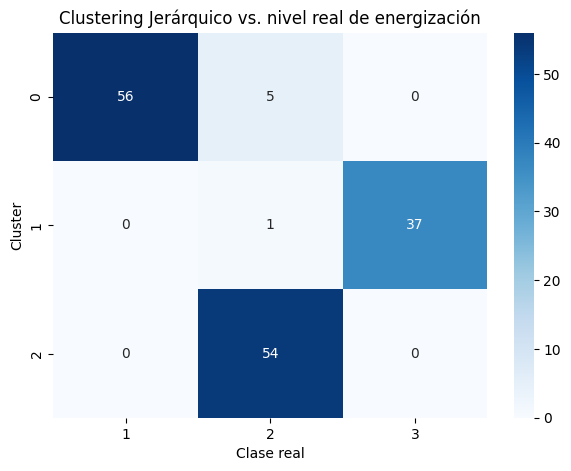

In [50]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    tabla_hierarchical,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Clustering Jerárquico vs. nivel real de energización")
plt.xlabel("Clase real")
plt.ylabel("Cluster")

plt.show()

#### Conclusión

El mapa de calor muestra una correspondencia muy clara entre los clusters obtenidos mediante Clustering Jerárquico y los niveles reales de energización.

- El **Cluster 0** contiene principalmente bebidas de **clase 1** (56 de 61).
- El **Cluster 1** contiene principalmente bebidas de **clase 3** (37 de 38).
- El **Cluster 2** contiene exclusivamente bebidas de **clase 2** (54 de 54).

Esto indica que la segmentación obtenida inicialmente, sin utilizar información sobre la energización, consiguió identificar grupos fuertemente relacionados con los resultados posteriores de las pruebas con clientes.

Las etiquetas de los clusters son arbitrarias, por lo que su numeración no tiene que coincidir con la de las clases reales.

#### 8.4.2 Adjusted Rand Index (ARI)

Para cuantificar la similitud entre la segmentación obtenida y las clases reales se utiliza el **Adjusted Rand Index (ARI)**.

Esta métrica permite comparar dos agrupaciones independientemente de la numeración utilizada para identificar sus grupos. Un valor próximo a 1 indica una alta coincidencia entre ambas particiones.

In [52]:
ari_hierarchical = adjusted_rand_score(
    y_original,
    labels_hierarchical
)

print(f"ARI Clustering Jerárquico: {ari_hierarchical:.4f}")

ARI Clustering Jerárquico: 0.8765


#### Conclusión del ARI

El Clustering Jerárquico obtiene un **Adjusted Rand Index de 0.8765**, un valor próximo a 1 que indica una alta correspondencia entre los clusters obtenidos inicialmente y los niveles reales de energización conocidos posteriormente.

Este resultado respalda cuantitativamente lo observado en el mapa de calor: aunque el modelo se construyó sin conocer los niveles de energización, la estructura encontrada mediante clustering presenta una fuerte relación con las clases reales.

### 8.5 Evaluación de DBSCAN

Se compara ahora la segmentación obtenida mediante DBSCAN con los niveles reales de energización.

En este caso se tendrá especialmente en cuenta la presencia de observaciones etiquetadas como **ruido (`-1`)**, además de la distribución de las clases reales dentro de los clusters encontrados.

In [53]:
tabla_dbscan = pd.crosstab(
    labels_dbscan,
    y_original,
    rownames=["Cluster"],
    colnames=["Clase real"]
)

tabla_dbscan

Clase real,1,2,3
Cluster,,,
-1,6,14,2
0,50,3,0
1,0,43,0
2,0,0,32
3,0,0,3


#### 8.5.1 Relación entre los clusters de DBSCAN y los niveles reales de energización

Se representa mediante un mapa de calor la distribución de las clases reales de energización dentro de los clusters obtenidos mediante DBSCAN.

En esta representación también se incluyen las observaciones clasificadas como ruido (`-1`) para analizar su relación con los niveles reales de energización.

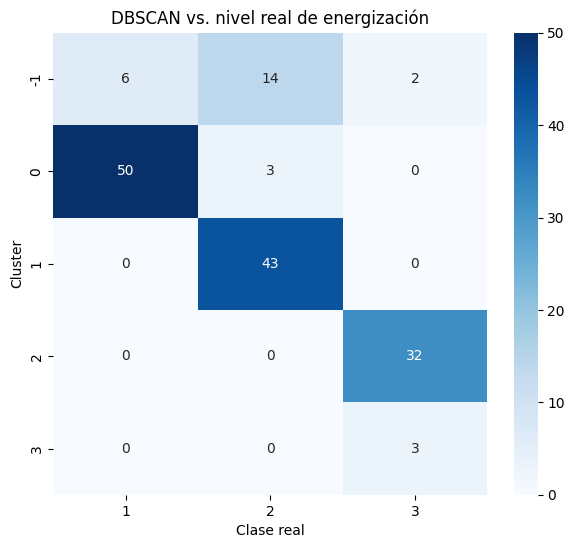

In [54]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    tabla_dbscan,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("DBSCAN vs. nivel real de energización")
plt.xlabel("Clase real")
plt.ylabel("Cluster")

plt.show()

#### Conclusión

El mapa de calor muestra que los clusters identificados por DBSCAN presentan una relación clara con los niveles reales de energización.

- El **Cluster 0** corresponde principalmente a la **clase 1**, con 50 de sus 53 observaciones.
- El **Cluster 1** está formado exclusivamente por observaciones de **clase 2**.
- Los **Clusters 2 y 3** están formados exclusivamente por observaciones de **clase 3**.
- Las 22 observaciones identificadas como **ruido (`-1`)** contienen bebidas pertenecientes a las tres clases reales, principalmente de clase 2.

DBSCAN consiguió, por tanto, identificar grupos muy homogéneos respecto al nivel de energización. Sin embargo, también separó la clase 3 en dos clusters distintos y dejó varias observaciones sin asignar a ningún segmento.

#### 8.5.2 Adjusted Rand Index (ARI)

Se calcula el Adjusted Rand Index para cuantificar la correspondencia entre los clusters obtenidos mediante DBSCAN y las clases reales de energización.

En este cálculo se mantienen también las observaciones identificadas como ruido (`-1`), ya que forman parte de la segmentación producida originalmente por el algoritmo.

In [55]:
ari_dbscan = adjusted_rand_score(
    y_original,
    labels_dbscan
)

print(f"ARI DBSCAN: {ari_dbscan:.4f}")

ARI DBSCAN: 0.6930


#### Conclusión del ARI

DBSCAN obtiene un **Adjusted Rand Index de 0.6930**, lo que indica una correspondencia considerable entre la segmentación obtenida inicialmente y los niveles reales de energización.

El resultado es coherente con el mapa de calor: DBSCAN identifica clusters muy homogéneos respecto a las clases reales, pero la presencia de observaciones clasificadas como ruido y la división de la clase 3 en dos clusters reducen la correspondencia global entre ambas particiones.

### 8.6 Comparación final de los modelos

Una vez disponibles los resultados reales de energización, se comparan ambos modelos mediante el **Adjusted Rand Index (ARI)**.

Esta comparación permite evaluar retrospectivamente qué segmentación presenta una mayor correspondencia con las clases obtenidas posteriormente en las pruebas con clientes.

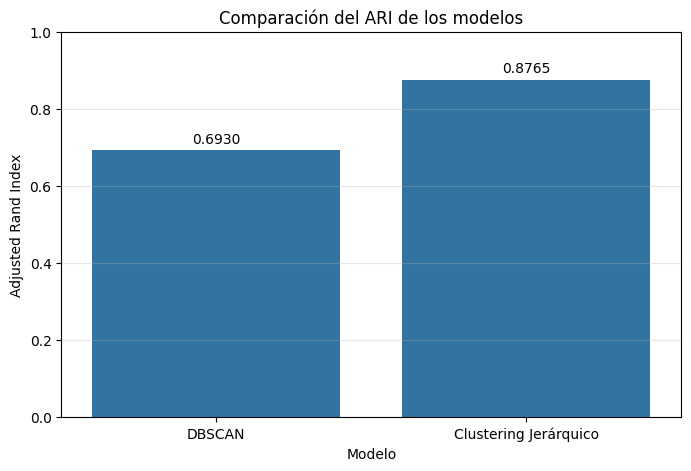

In [61]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=resultados_ari,
    x="Modelo",
    y="ARI"
)

plt.ylim(0, 1)
plt.title("Comparación del ARI de los modelos")
plt.ylabel("Adjusted Rand Index")
plt.xlabel("Modelo")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.show()

#### Conclusión de la comparación

Ambos modelos presentan una relación clara entre los segmentos obtenidos inicialmente y los niveles reales de energización conocidos posteriormente.

El **Clustering Jerárquico obtiene un ARI de 0.8765**, mientras que **DBSCAN obtiene un ARI de 0.6930**. En esta evaluación retrospectiva, la partición obtenida mediante Clustering Jerárquico presenta una mayor correspondencia con las clases reales.

DBSCAN también identifica grupos muy homogéneos, pero clasifica 22 observaciones como ruido y divide las bebidas de clase 3 en dos clusters diferentes, lo que reduce la correspondencia global entre ambas particiones.

Estos resultados permiten confirmar que la segmentación obtenida sin disponer inicialmente de una variable objetivo sí estaba relacionada con los niveles de energización observados posteriormente.

### 8.7 Análisis visual de los niveles reales de energización

Una vez conocidos los resultados de las pruebas con clientes, se analiza visualmente cómo se distribuyen las principales características de las bebidas según su nivel real de energización.

Esto permite observar qué componentes presentan diferencias entre las clases y ayuda a interpretar por qué los algoritmos de clustering fueron capaces de identificar una estructura similar sin disponer inicialmente de esta información.

In [62]:
df_evaluacion = X.copy()

df_evaluacion["class"] = y_original.values

df_evaluacion.head()

,Azúcares,Cafeína,Ácido Cítrico,Taurina,class
0,1.518613,1.034819,1.013009,0.251717,1
1,0.246290,0.733629,0.965242,-0.293321,1
2,0.196879,1.215533,1.395148,0.269020,1
3,1.691550,1.466525,2.334574,1.186068,1
4,0.295700,0.663351,-0.037874,-0.319276,1


#### 8.7.1 Distribución de las features según el nivel de energización

Se comparan las distribuciones de las cuatro features seleccionadas para cada nivel real de energización mediante histogramas superpuestos.

La transparencia permite observar las zonas de solapamiento y aquellas en las que las clases presentan comportamientos diferenciados.

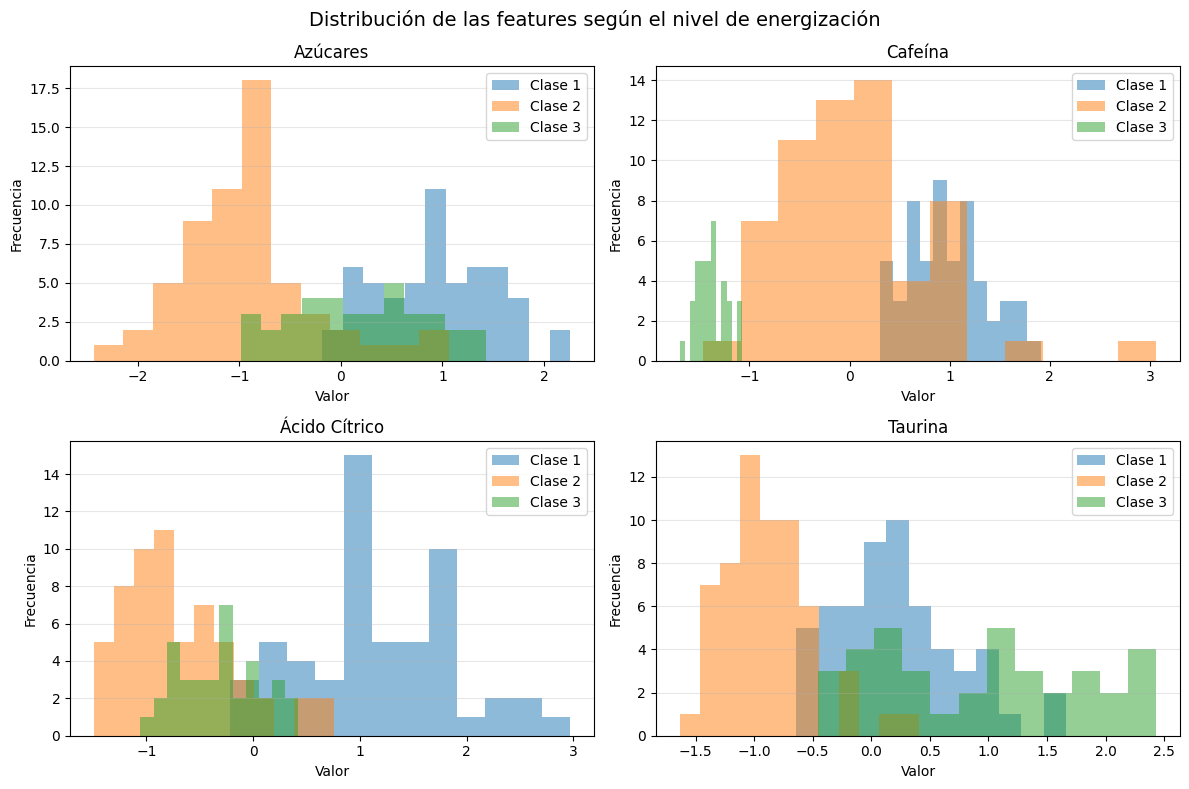

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for i, feature in enumerate(features):
    
    for clase in sorted(df_evaluacion["class"].unique()):
        
        axes[i].hist(
            df_evaluacion.loc[
                df_evaluacion["class"] == clase,
                feature
            ],
            bins=12,
            alpha=0.5,
            label=f"Clase {clase}"
        )
    
    axes[i].set_title(feature)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(axis="y", alpha=0.3)
    axes[i].legend()

plt.suptitle(
    "Distribución de las features según el nivel de energización",
    fontsize=14
)

plt.tight_layout()

plt.show()

#### Conclusión

Las distribuciones muestran que los niveles reales de energización presentan diferencias en la composición de las bebidas.

La **Cafeína, el Ácido Cítrico y la Taurina** muestran patrones especialmente diferenciados entre las clases, aunque existe cierto solapamiento entre ellas. Los **Azúcares** también aportan información, especialmente en la diferenciación de la clase 2.

Estas diferencias ayudan a explicar por qué los algoritmos de clustering fueron capaces de identificar segmentos relacionados con los niveles de energización sin disponer inicialmente de esta variable objetivo.

No obstante, ninguna feature por sí sola separa completamente las tres clases, por lo que la estructura encontrada depende de la combinación de varias características.

#### 8.7.2 Visualización de las clases reales

Finalmente, se representa la relación entre Cafeína y Taurina utilizando los niveles reales de energización para comparar visualmente esta estructura con la obtenida mediante clustering.

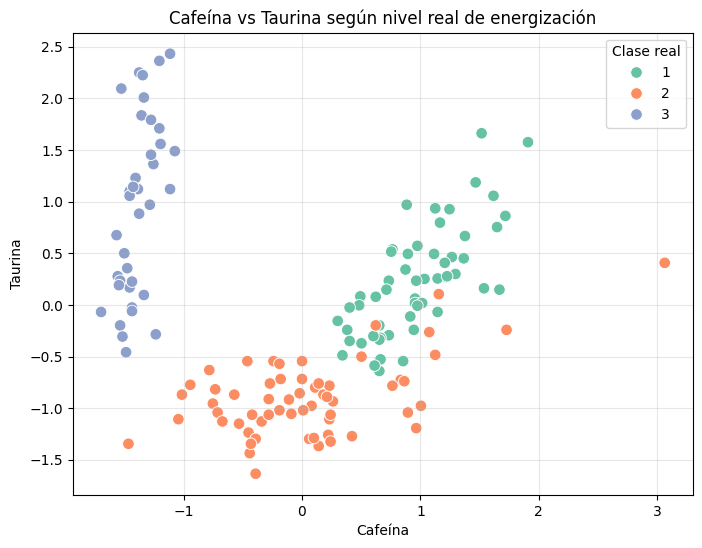

In [64]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_evaluacion,
    x="Cafeína",
    y="Taurina",
    hue="class",
    palette="Set2",
    s=70
)

plt.title("Cafeína vs Taurina según nivel real de energización")
plt.xlabel("Cafeína")
plt.ylabel("Taurina")
plt.legend(title="Clase real")
plt.grid(alpha=0.3)

plt.show()

## 9. Conclusiones finales

En este ejercicio se aplicaron técnicas de **aprendizaje no supervisado** para segmentar diferentes formulaciones de bebidas energéticas a partir de su composición, sin disponer inicialmente de una variable objetivo.

Se utilizaron dos enfoques de clustering:

- **DBSCAN**, que permitió identificar grupos y detectar observaciones consideradas como ruido.
- **Clustering Jerárquico**, que permitió obtener una segmentación completa de las bebidas y analizar la relación entre los grupos mediante el dendrograma.

Los resultados mostraron que existía una estructura clara en los datos. El Clustering Jerárquico generó **3 clusters**, mientras que la configuración seleccionada de DBSCAN identificó **4 clusters y 22 observaciones como ruido**.

Para los nuevos experimentos se utilizó la segmentación jerárquica, asignándolos al cluster cuyo centroide se encontraba más próximo según las cuatro características seleccionadas.

Finalmente, al disponer de los resultados reales de energización obtenidos posteriormente con clientes, fue posible evaluar retrospectivamente las segmentaciones. El **Clustering Jerárquico obtuvo un ARI de 0.8765**, frente al **0.6930 de DBSCAN**, mostrando una mayor correspondencia con los tres niveles reales de energización.

Las visualizaciones finales también mostraron diferencias claras entre las clases reales, especialmente en variables como **Cafeína, Ácido Cítrico y Taurina**.

En conjunto, el ejercicio muestra cómo las técnicas de clustering pueden descubrir estructuras relevantes en los datos incluso cuando inicialmente no existe una variable objetivo conocida.